# Логистическая регрессия

## Литература

* Специализация "Машинное обучение и анализ данных" от МФТИ и Яндекса на Coursera
* [Открытый курс машинного обучения. Тема 4. Линейные модели классификации и регрессии](https://habr.com/ru/companies/ods/articles/323890/)
* [Логистическая регрессия](http://www.machinelearning.ru/wiki/index.php?title=%D0%9B%D0%BE%D0%B3%D0%B8%D1%81%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%81%D0%B8%D1%8F)

In [1]:
import matplotlib.pyplot as plt
import numpy as np

## Теория

Логистическая регрессия – это не регрессия в обычном смысле, а метод бинарной классификации. В отличие от линейной регрессии, где мы предсказываем число, здесь мы предсказываем вероятность принадлежности объекта к одному из двух классов. Модель остаётся линейной по параметрам, но ответ "пропускается" через сигмоидную функцию, чтобы превратить линейную комбинацию признаков в вероятность.

Метод логистической регрессии строит линейный классификатор, позволяющий оценивать апостериорные вероятности принадлежности объектов классам. Мы предполагаем, что наша выборка является линейно разделимой: признаковое пространство может быть линейно разделено при помощи гиперплоскости на два подпространства: в одном будут лежать объекты с меткой класса "+1", а в другом - "-1".

### Задача

* Множество объектов-ответов
    * Каждый объект описан множеством объясняющих факторов: $x_j \in R^M$
    * Каждый объект имеет соответствующую метку: $y \in \{+1, -1\}$
    * Задается линейная модель классификации:

$$a(\vec{x}) = sign(\vec{w}^T\vec{x}) = sign(\langle w, x \rangle)$$

где 
* $\vec{w}$ – веса в линейной модели (вместе со смещением $w_0$) - $\vec{w} \in R^{M+1}$
* $a(\vec{x})$ – ответ классификатора на примере $\vec{x}$

Уравнение $\vec{w}^T\vec{x} = 0$ задает гиперплоскость, разделяющую примеры на 2 класса.

### Переход от линейной регрессии к логистической

Линейная регрессия – модель, которая предсказывает **непрерывную целевую переменную** $y \in \mathbb{R}$ как линейную комбинацию признаков:

$$
\hat{y} = w_0 + w_1 x_1 + \dots + w_m x_m = \mathbf{w}^T \mathbf{x}.
$$

Такой подход отлично работает, когда мы хотим спрогнозировать цену дома, температуру или пробег автомобиля. Но что, если наша задача – **классификация**, то есть предсказание **категориальной** метки, например, «спам / не спам», «болен / здоров», «клиент уйдёт / останется»? Здесь ответ – это дискретная переменная, часто принимающая значения $0$ и $1$ (или $-1$ и $+1$).

### Линейный дискриминант Фишера как первый подход

В 1936 году Рональд Фишер предложил использовать линейную регрессию для задачи классификации. Идея была проста: закодировать классы числами, например, $y \in \{-1, +1\}$, и обучить модель, минимизирующую среднеквадратичную ошибку (МНК):

$$
\mathcal{L} = \frac{1}{n} \sum_{i=1}^n \left( \mathbf{w}^T \mathbf{x}_i - y_i \right)^2.
$$

Тогда $w_* = \text{argmin}_a \mathcal{L}(w, X)$

После нахождения весов $\mathbf{w}$ классификационное правило выглядело так: 
* $\langle w, x_i \rangle > 0.5$ - объект относится к классу $y = +1$
* $\langle w, x_i \rangle \leq 0.5$ - объект относится к классу $y = -1$

Этот метод получил название **линейный дискриминант Фишера** (LDF).

Однако у этого подхода есть серьёзные ограничения:

1. **Произвольность порога.** Выбор порога 0.5 не имеет теоретического обоснования и зависит от данных. Можно подобрать другой порог, но это уже становится дополнительным гиперпараметром.

2. **Нет интерпретации вероятности.** Предсказание $\mathbf{w}^T \mathbf{x}$ может принимать любые значения, в том числе далеко за пределами $[0, 1]$. Мы не можем сказать: «с вероятностью 80% этот объект относится к классу +1». А именно вероятностный прогноз часто нужен в реальных задачах – для оценки рисков, принятия решений или калибровки модели.

3. **Чувствительность к выбросам.** МНК стремится минимизировать квадрат ошибки, поэтому объекты, которые уже правильно классифицированы, но находятся далеко от разделяющей гиперплоскости, продолжают «тянуть» веса, что может искажать решение.

Таким образом, дискриминант Фишера даёт **линейную разделяющую границу**, но не даёт нам **вероятностной меры**. Нам нужно нечто большее – модель, которая бы предсказывала не просто знак, а степень уверенности в этом знаке.

### Сигмоида - от линейной комбинации к вероятности

Чтобы получить вероятность $p \in [0, 1]$, нам нужно каким-то образом **преобразовать** линейную комбинацию $z = \mathbf{w}^T \mathbf{x}$, которая может быть любой, в интервал $(0, 1)$. И здесь на помощь приходит **сигмоидная функция** (логистическая функция):

$$
\sigma(z) = \frac{1}{1 + e^{-z}}.
$$

Её график имеет характерную S-образную форму и обладает замечательными свойствами:

1. **Ограниченность:** $\sigma(z) \in (0, 1)$ для любого действительного $z$.
2. **Монотонность:** функция строго возрастает, что сохраняет порядок – чем больше $z$, тем выше вероятность.
3. **Простая производная:** $\sigma'(z) = \sigma(z) \cdot (1 - \sigma(z))$. Это свойство критически важно для градиентного спуска, потому что производная выражается через саму функцию, что упрощает вычисления.
4. **Симметрия:** $\sigma(-z) = 1 - \sigma(z)$.

Теперь мы можем определить **логистическую регрессию** следующим образом:

$$
p_+(\mathbf{x}) = P(y_i = +1 \mid \vec{x_i}, \vec{w}) = \sigma(\mathbf{w}^T \mathbf{x}) = \frac{1}{1 + e^{-\mathbf{w}^T \mathbf{x}}}.
$$

То есть мы по-прежнему используем линейную комбинацию признаков (как в дискриминанте Фишера), но затем «пропускаем» её через сигмоиду, получая осмысленную вероятность. Классификационное правило тогда естественно: если $p_+(\mathbf{x}) > 0.5$, предсказываем класс 1, иначе класс 0. Заметим, что граница $p_+ = 0.5$ соответствует $\mathbf{w}^T \mathbf{x} = 0$ – это уравнение гиперплоскости, которая разделяет пространство признаков на две области. Таким образом, логистическая регрессия наследует геометрическую идею Фишера, но добавляет вероятностную интерпретацию.

In [2]:
def sigmoid(z):
    sig = 1.0 / (1.0 + np.exp(-z))
    sig = np.minimum(sig, 0.9999999)
    sig = np.maximum(sig, 0.0000001)
    return sig

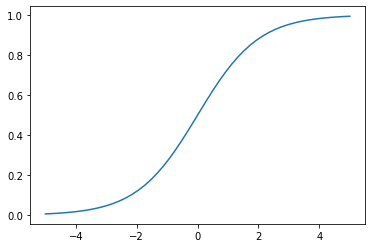

In [3]:
x = np.linspace(-5, 5)
y = sigmoid(x)

fig, ax = plt.subplots()
ax.plot(x, y);

In [4]:
# Не должно равняться 1
sigmoid(100000)

0.9999999

### Геометрическая интерпретация: отступ

Рассмотрим выражение $\mathbf{w}^T \mathbf{x}$. Для объекта $\mathbf{x}_i$ с истинной меткой $y_i \in \{+1, -1\}$ (перекодируем для удобства) введём понятие **отступа** (margin):

$$
M_i = y_i \cdot \mathbf{w}^T \mathbf{x}_i.
$$

Отступ показывает, насколько «уверенно» классификатор относит объект к правильному классу:

- Если $M_i > 0$, объект классифицируется **верно**, и чем больше $M_i$, тем дальше он от разделяющей гиперплоскости – тем выше уверенность.
- Если $M_i < 0$, объект классифицируется **ошибочно**.
- $|M_i|$ пропорционален расстоянию от точки $\mathbf{x}_i$ до гиперплоскости $\mathbf{w}^T \mathbf{x} = 0$ (с точностью до нормы $\|\mathbf{w}\|$).

В терминах отступа вероятность правильной классификации можно записать как:

$$
P(y_i \mid \mathbf{x}_i, \mathbf{w}) = \sigma(y_i \cdot \mathbf{w}^T \mathbf{x}_i) = \sigma(M_i).
$$

Таким образом, логистическая регрессия максимизирует вероятность того, что отступ будет положительным и по возможности большим. Это прямое обобщение идеи Фишера: мы не просто ищем гиперплоскость, разделяющую классы, но и стремимся к тому, чтобы объекты располагались как можно дальше от неё, причём в вероятностном смысле.

### Связь с отношением шансов (odds)

Перепишем формулу для вероятности:

$$
p_+ = \frac{1}{1 + e^{-z}} \quad \Longrightarrow \quad \frac{p_+}{1 - p_+} = e^{z} = e^{\mathbf{w}^T \mathbf{x}}.
$$

Величина $\frac{p_+}{1 - p_+}$ называется **шансами** (odds) – отношение вероятности того, что событие произойдёт, к вероятности того, что оно не произойдёт. 

**Логарифм шансов** (логит) для положительного класса:

$$
\log\left(\frac{p_+}{1 - p_+}\right) = \mathbf{w}^T \mathbf{x},
$$

где $p_+ = P(y = +1 \mid \mathbf{x})$.

Логарифм шансов – это **линейная функция** признаков. Именно поэтому модель называется **логистической регрессией**: мы регрессируем (предсказываем) логарифм шансов как линейную комбинацию. Это даёт очень естественную интерпретацию: каждый признак $x_j$ вносит аддитивный вклад в логарифм шансов, а его вес $w_j$ показывает, насколько изменение этого признака влияет на шансы.

Таким образом, логистическая регрессия **исправляет** недостатки дискриминанта Фишера, сохраняя его простоту и линейность, но добавляя вероятностную основу, строгую функцию потерь и возможность оценивать неопределённость прогноза.

Напомним, что логистическая регрессия задаёт вероятность положительного класса:

$$p_+ = \sigma(\mathbf{w}^T \mathbf{x}) = \frac{1}{1 + e^{-\mathbf{w}^T \mathbf{x}}}.$$

Вероятность правильной классификации для объекта с меткой $y_i$ равна:

$$P(y_i \mid \mathbf{x}_i) = \sigma(y_i \cdot \mathbf{w}^T \mathbf{x}_i) = \sigma(M_i).$$

Теперь рассмотрим **шансы правильной классификации**:

$$\text{Odds}_i = \frac{P(y_i \mid \mathbf{x}_i)}{1 - P(y_i \mid \mathbf{x}_i)}.$$

Подставим $\sigma(M_i)$:

$$\text{Odds}_i = \frac{\sigma(M_i)}{1 - \sigma(M_i)}.$$

Используем фундаментальное свойство сигмоиды:

$$\frac{\sigma(z)}{1 - \sigma(z)} = e^{z}.$$

Получаем:

$$\text{Odds}_i = e^{M_i}.$$

Логарифмируя:

$$\log(\text{Odds}_i) = M_i$$

**Отступ $M_i$ — это логарифм шансов того, что модель правильно классифицирует объект $\mathbf{x}_i$.**

- Если $M_i = 0$, шансы равны $1:1$ — модель не уверена (вероятность правильной классификации = 0.5).
- Если $M_i = 2$, шансы равны $e^2 \approx 7.4:1$ — модель сильно уверена в правильности.
- Если $M_i = -2$, шансы равны $e^{-2} \approx 0.14:1$ — модель склонна ошибиться.

**Для объекта с меткой $y_i = +1$:**

$$
M_i = \mathbf{w}^T \mathbf{x}_i = \log\left(\frac{p_+}{1 - p_+}\right).
$$

То есть отступ совпадает с логарифмом шансов положительного класса.

**Для объекта с меткой $y_i = -1$:**

$$
M_i = -\mathbf{w}^T \mathbf{x}_i = \log\left(\frac{p_-}{1 - p_-}\right),
$$

где $p_- = 1 - p_+$ — вероятность отрицательного класса.

### Обучение логистической регрессии

В отличие от линейной регрессии, для логистической регрессии **не существует аналитического решения** (замкнутой формулы для весов). Поэтому мы вынуждены использовать численные методы оптимизации, например, **градиентный спуск**. Функция потерь строится на основе принципа **максимального правдоподобия**. Правдоподобие выборки - вероятность наблюдать вектор $\vec{y}$ у выборки $X$.

Даны объекты обучающей выборки, для которых можно вычислить $P(y = y_i \mid \vec{x_i}, \vec{w}) = \sigma(y_i\vec{w}^T\vec{x_i})$. 

Делаем сильное предположение: объекты приходят независимо, из одного распределения, тогда:

$P(\vec{y} \mid X, \vec{w}) = \prod_{i=1}^{\ell} P(y = y_i \mid \vec{x_i}, \vec{w}),$

где $\ell$ – длина выборки $X$ (число строк).

Как водится, возьмем логарифм данного выражения (сумму оптимизировать намного проще, чем произведение):

$ \log P(\vec{y} \mid X, \vec{w}) = \log \prod_{i=1}^{\ell} P(y = y_i \mid \vec{x_i}, \vec{w})  = \log \prod_{i=1}^{\ell} \sigma(y_i\vec{w}^T\vec{x_i})  = \sum_{i=1}^{\ell} \log \sigma(y_i\vec{w}^T\vec{x_i}) = \sum_{i=1}^{\ell} \log \frac{1}{1 + \exp^{-y_i\vec{w}^T\vec{x_i}}} = - \sum_{i=1}^{\ell} \log (1 + \exp^{-y_i\vec{w}^T\vec{x_i}})$

То есть в даном случае принцип максимизации правдоподобия приводит к минимизации выражения

$ \mathcal{L_{log}} (X, \vec{y}, \vec{w}) = \sum_{i=1}^{\ell} \log (1 + \exp^{-y_i\vec{w}^T\vec{x_i}})$

Это логистическая функция потерь, просуммированная по всем объектам обучающей выборки.

Посмотрим на новую фунцию как на функцию от отступа: $L(M) = \log (1 + \exp^{-M})$. Нарисуем ее график, а также график 1/0 функциий потерь (zero-one loss), которая просто штрафует модель на 1 за ошибку на каждом объекте (отступ отрицательный): $L_{1/0}(M) = [M < 0]$.

Картинка отражает общую идею, что в задаче классификации, не умея напрямую минимизировать число ошибок (по крайней мере, градиентными методами это не сделать – производная 1/0 функциий потерь в нуле обращается в бесконечность), мы минимизируем некоторую ее верхнюю оценку. В данном случае это логистическая функция потерь (где логарифм двоичный, но это не принципиально), и справедливо

$ \mathcal{L_{1/0}} (X, \vec{y}, \vec{w}) = \sum_{i=1}^{\ell} [M(\vec{x_i}) < 0]  \leq \sum_{i=1}^{\ell} \log (1 + \exp^{-y_i\vec{w}^T\vec{x_i}})  = \mathcal{L_{log}} (X, \vec{y}, \vec{w})$

где $\mathcal{L_{1/0}} (X, \vec{y}, \vec{w})$ – попросту число ошибок логистической регрессии с весами $\vec{w}$ на выборке $(X, \vec{y})$.

То есть уменьшая верхнюю оценку $\mathcal{L_{log}}$ на число ошибок классификации, мы таким образом надеемся уменьшить и само число ошибок.

Итак, мы свели задачу к минимизации функции $\mathcal{L_{log}}(\vec{w})$. Поскольку она **выпуклая** и **дифференцируемая**, мы можем использовать градиентный спуск. Нам необходимо вычислить градиент — вектор частных производных по каждому весу $w_j$.

Для:

$$
\mathcal{L_{log}} (\vec{w}) = \sum_{i=1}^{\ell} \log (1 + \exp^{-y_i \vec{w}^T \vec{x}_i}).
$$

Возьмём производную по $w_j$:

$$
\frac{\partial \mathcal{L_{log}}}{\partial w_j} = \sum_{i=1}^{\ell} \frac{1}{1 + \exp^{-y_i \vec{w}^T \vec{x}_i}} \cdot \exp^{-y_i \vec{w}^T \vec{x}_i} \cdot (-y_i x_{ij}).
$$

Упростим, используя свойство сигмоиды: $\sigma(z) = \frac{1}{1 + e^{-z}}$. Тогда:

$$
\frac{\partial \mathcal{L_{log}}}{\partial w_j} = - \sum_{i=1}^{\ell} y_i x_{ij} \cdot \frac{\exp^{-y_i \vec{w}^T \vec{x}_i}}{1 + \exp^{-y_i \vec{w}^T \vec{x}_i}} = - \sum_{i=1}^{\ell} y_i x_{ij} \cdot \sigma(-y_i \vec{w}^T \vec{x}_i).
$$

А поскольку $\sigma(-z) = 1 - \sigma(z)$, получаем:

$$
\frac{\partial \mathcal{L_{log}}}{\partial w_j} = - \sum_{i=1}^{\ell} y_i x_{ij} \left( 1 - \sigma(y_i \vec{w}^T \vec{x}_i) \right).
$$

В векторной форме (если использовать метки $y_i \in \{0, 1\}$ и вероятности $p_i = \sigma(\vec{w}^T \vec{x}_i)$) градиент записывается ещё компактнее:

$$
\nabla \mathcal{L_{log}}(\vec{w}) = \sum_{i=1}^{\ell} (p_i - y_i) \vec{x}_i,
$$

или в матричной форме (с нормировкой на количество объектов):

$$
\nabla \mathcal{L_{log}}(\vec{w}) = \frac{1}{\ell} X^T (\mathbf{p} - \mathbf{y}),
$$

где $\mathbf{p} = \sigma(X\vec{w})$ — вектор предсказанных вероятностей.

Теперь мы можем обновлять веса итеративно:

$$
\vec{w}^{(t+1)} = \vec{w}^{(t)} - \eta \nabla \mathcal{L_{log}}(\vec{w}^{(t)}),
$$

где $\eta$ – скорость обучения (learning rate).

Благодаря выпуклости функции потерь, при правильном выборе $\eta$ и достаточном числе итераций, градиентный спуск гарантированно сойдётся к глобальному минимуму. Критерием остановки может служить малое изменение функции потерь между итерациями или достижение максимального числа шагов.

### Прогноз логистической регрессии

После того как модель обучена и веса $\mathbf{w}$ найдены, прогноз для нового объекта $\mathbf{x}$ выполняется в два шага:

1. **Вычисление вероятности** положительного класса:

$$
p_+ = \sigma(\mathbf{w}^T \mathbf{x}) = \frac{1}{1 + e^{-\mathbf{w}^T \mathbf{x}}}.
$$

2. **Принятие решения** о классе на основе порога (обычно 0.5):

$$
\hat{y} = 
\begin{cases} 
1, & p_+ \ge 0.5, \\
0, & p_+ < 0.5.
\end{cases}
$$

При необходимости порог можно менять, чтобы управлять компромиссом между полнотой (recall) и точностью (precision) – это особенно полезно в задачах с несбалансированными классами.

### Практическая задача

In [5]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

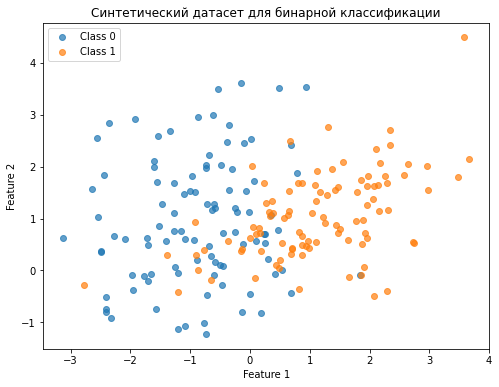

In [6]:
X, y = make_classification(
    n_samples=200, n_features=2, n_informative=2, 
    n_redundant=0, n_clusters_per_class=1, random_state=42
)

y_binary = y.copy()

plt.figure(figsize=(8, 6))
plt.scatter(X[y==0, 0], X[y==0, 1], label='Class 0', alpha=0.7)
plt.scatter(X[y==1, 0], X[y==1, 1], label='Class 1', alpha=0.7)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.title('Синтетический датасет для бинарной классификации')
plt.show()

In [7]:
class LogisticRegressionGradientDescent:
    """
    Реализация логистической регрессии с использованием градиентного спуска
    для минимизации логистической функции потерь (Log Loss).
    """
    def __init__(self, learning_rate=0.1, n_iterations=1000, threshold=1e-6, add_intercept=True):
        """
        :param learning_rate: шаг градиентного спуска (eta)
        :param n_iterations: максимальное число итераций
        :param threshold: порог для ранней остановки по изменению функции потерь
        :param add_intercept: добавлять ли свободный член (intercept)
        """
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.threshold = threshold
        self.add_intercept = add_intercept
        self.weights = None
        self.loss_history = []

    def _sigmoid(self, z):
        """Сигмоидная функция с клиппингом для численной стабильности."""
        z = np.clip(z, -500, 500)
        sig = 1.0 / (1.0 + np.exp(-z))
        sig = np.clip(sig, 1e-10, 1 - 1e-10)
        return sig

    def _add_intercept_column(self, X):
        """Добавляет столбец единиц к матрице признаков."""
        if self.add_intercept:
            intercept = np.ones((X.shape[0], 1))
            return np.hstack((intercept, X))
        return X

    def fit(self, X, y):
        """
        Обучение модели на данных (X, y).

        :param X: матрица признаков (n_samples, n_features)
        :param y: вектор целевых меток (n_samples,), значения должны быть 0 или 1
        """
        X = np.array(X)
        y = np.array(y)

        y_transformed = np.where(y == 0, -1, 1)
        X_with_intercept = self._add_intercept_column(X)
        self.weights = np.zeros(X_with_intercept.shape[1])
        self.loss_history = []

        for i in range(self.n_iterations):
            linear_output = np.dot(X_with_intercept, self.weights)
            probabilities = self._sigmoid(linear_output)
            
            loss = -np.mean(y * np.log(probabilities) + (1 - y) * np.log(1 - probabilities))
            self.loss_history.append(loss)
            
            gradient = np.dot(X_with_intercept.T, (probabilities - y)) / X.shape[0]
            self.weights -= self.learning_rate * gradient

            if i > 0 and abs(self.loss_history[-1] - self.loss_history[-2]) < self.threshold:
                print(f"Ранняя остановка на итерации {i}.")
                break

    def predict_proba(self, X):
        """Возвращает вероятности принадлежности к классу 1 для каждого объекта."""
        X = np.array(X)
        X_with_intercept = self._add_intercept_column(X)
        linear_output = np.dot(X_with_intercept, self.weights)
        return self._sigmoid(linear_output)

    def predict(self, X, threshold=0.5):
        """Возвращает предсказанные метки классов (0 или 1)."""
        probabilities = self.predict_proba(X)
        return (probabilities >= threshold).astype(int)

    def score(self, X, y):
        """Возвращает долю правильных ответов (accuracy)."""
        predictions = self.predict(X)
        return np.mean(predictions == y)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.3, random_state=42)

model_custom = LogisticRegressionGradientDescent(learning_rate=0.5, n_iterations=10000, threshold=1e-6)
model_custom.fit(X_train, y_train)

model_sklearn = LogisticRegression()
model_sklearn.fit(X_train, y_train)

accuracy_custom = model_custom.score(X_test, y_test)
accuracy_sklearn = model_sklearn.score(X_test, y_test)

print(f"Точность (accuracy) на тестовой выборке (наша реализация): {accuracy_custom:.4f}")
print(f"Точность (accuracy) на тестовой выборке (sklearn): {accuracy_sklearn:.4f}")

print("\nВеса модели (наша реализация):")
print(f"w0 (intercept): {model_custom.weights[0]:.4f}")
print(f"w1, w2: {model_custom.weights[1:]}")

print("\nВеса модели (sklearn):")
print(f"w0 (intercept): {model_sklearn.intercept_[0]:.4f}")
print(f"w1, w2: {model_sklearn.coef_[0]}")

Ранняя остановка на итерации 168.
Точность (accuracy) на тестовой выборке (наша реализация): 0.8833
Точность (accuracy) на тестовой выборке (sklearn): 0.8667

Веса модели (наша реализация):
w0 (intercept): 0.5154
w1, w2: [ 1.97151785 -0.55485297]

Веса модели (sklearn):
w0 (intercept): 0.4669
w1, w2: [ 1.80054542 -0.49363523]
